In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [13]:
url = "https://raw.githubusercontent.com/4GeeksAcademy/linear-regression-project-tutorial/main/medical_insurance_cost.csv"
medical_insurance = pd.read_csv(url)

In [14]:
medical_insurance.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [15]:
print(medical_insurance.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB
None


In [16]:
print(medical_insurance.isnull().sum())


age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64


- No hay valores nulos en el dataset.


In [17]:
cat_vars = medical_insurance.select_dtypes(include=['object']).columns.tolist()
print("Variables categóricas:", cat_vars)

num_vars = medical_insurance.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Variables numéricas:", num_vars)

Variables categóricas: ['sex', 'smoker', 'region']
Variables numéricas: ['age', 'bmi', 'children', 'charges']


In [18]:
medical_insurance[num_vars].describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


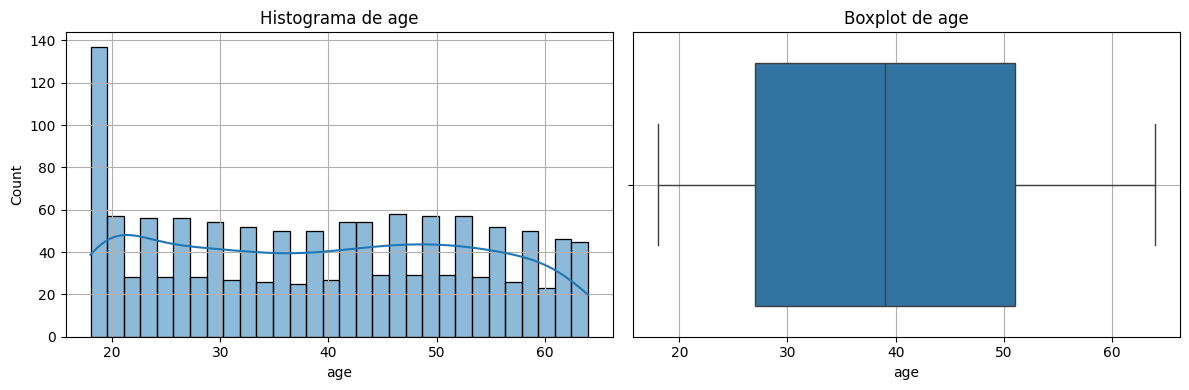

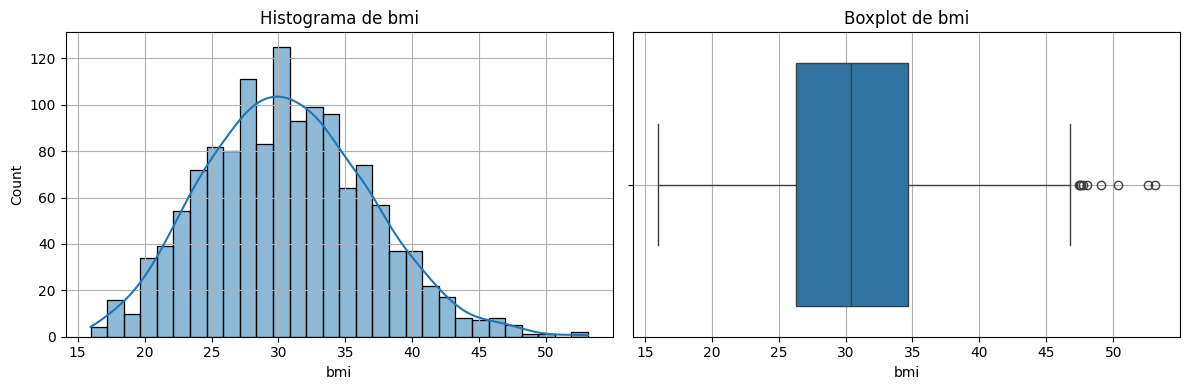

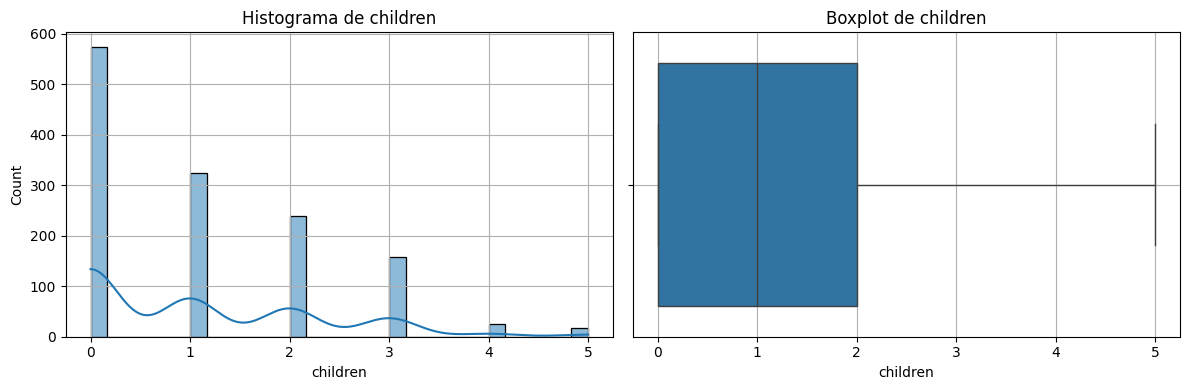

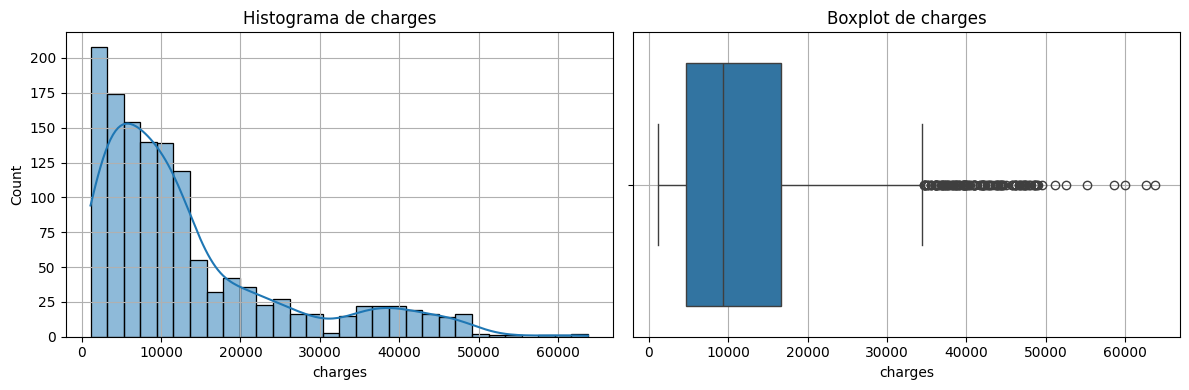

In [19]:
for col in num_vars:
    fig, axs = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(medical_insurance[col], kde=True, bins=30, ax=axs[0])
    axs[0].set_title(f"Histograma de {col}")
    axs[0].grid(True)
    
    sns.boxplot(x=medical_insurance[col], ax=axs[1])
    axs[1].set_title(f"Boxplot de {col}")
    axs[1].grid(True)

    plt.tight_layout()
    plt.show()

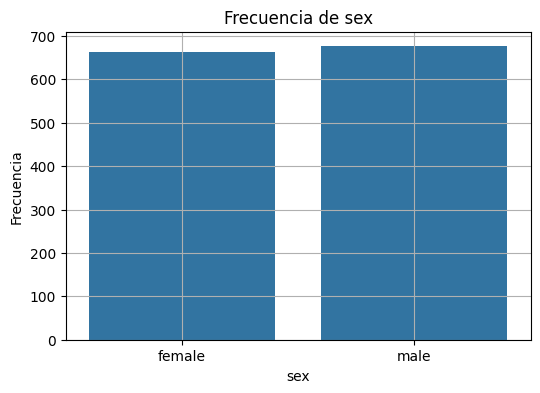

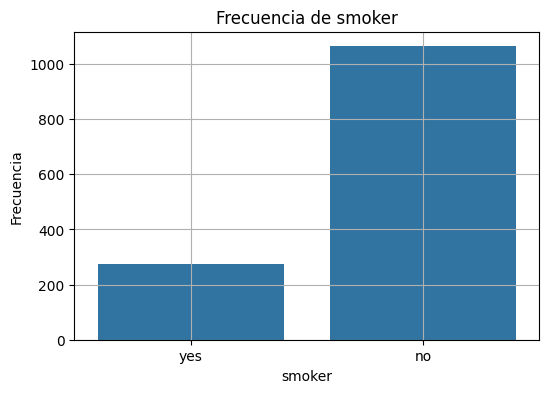

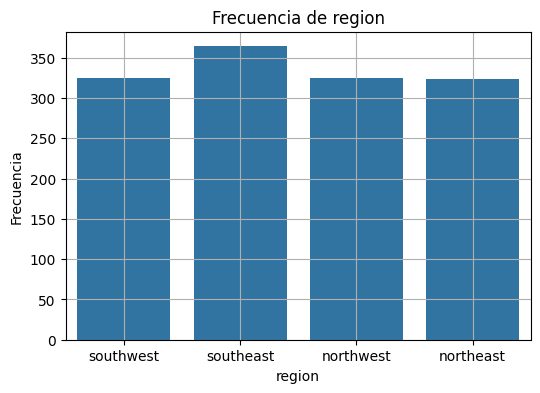

In [20]:
for col in cat_vars:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=medical_insurance, x=col)
    plt.title(f"Frecuencia de {col}")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")
    plt.grid(True)
    plt.show()


#  Análisis Multivariado
### Matriz de correlación

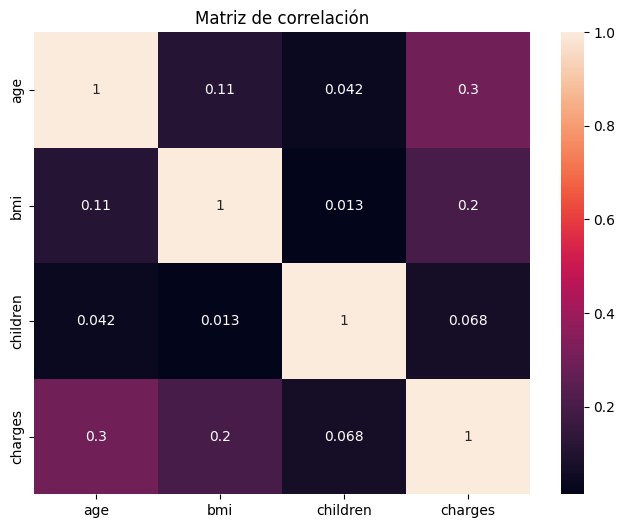

In [21]:


plt.figure(figsize=(8, 6))
sns.heatmap(medical_insurance[num_vars].corr(), annot=True)
plt.title("Matriz de correlación")
plt.show()

- La variable `bmi` muestra una correlación positiva moderada con `charges` en la matriz de correlación.

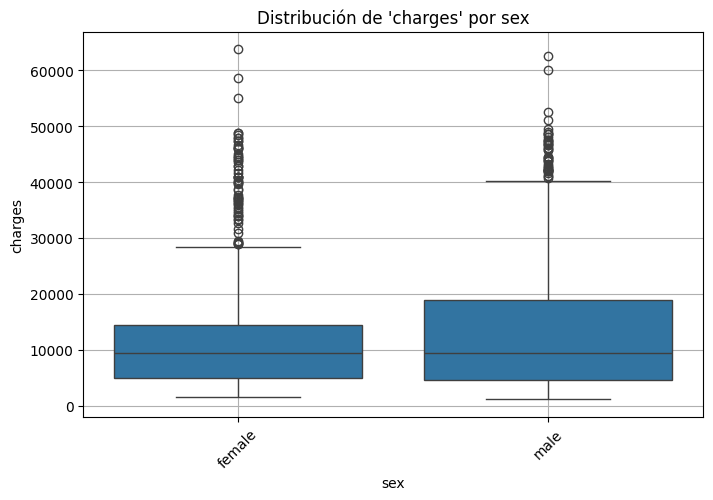

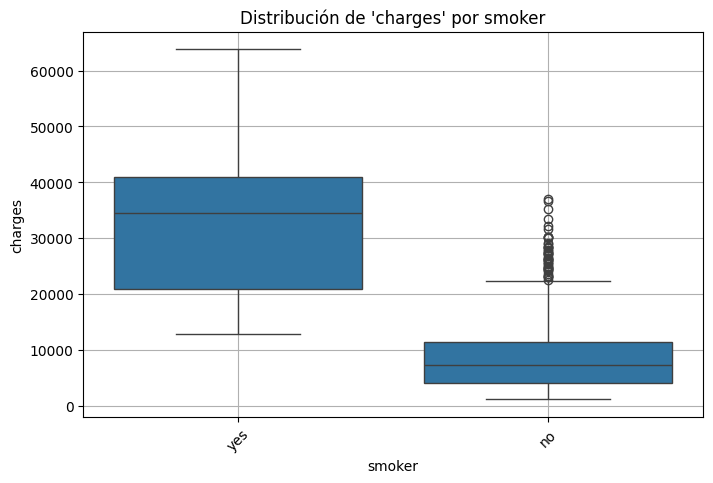

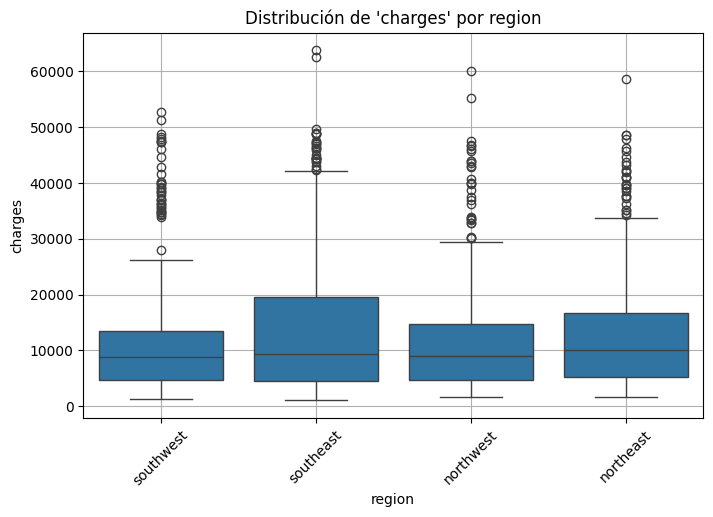

In [22]:
# Boxplots entre variables categóricas y la prima (charges)
for col in cat_vars:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=medical_insurance, x=col, y='charges')
    plt.title(f"Distribución de 'charges' por {col}")
    plt.xticks(rotation=45)
    plt.grid(True)
    plt.show()

- La variable `smoker` muestra una clara diferencia en las primas (`charges`) entre fumadores y no fumadores, observada en los boxplots.

age: 0 outliers encontrados


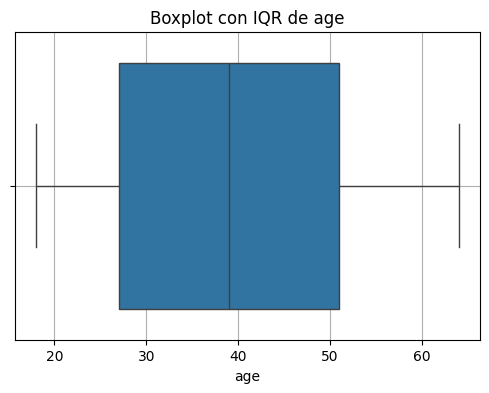

bmi: 9 outliers encontrados


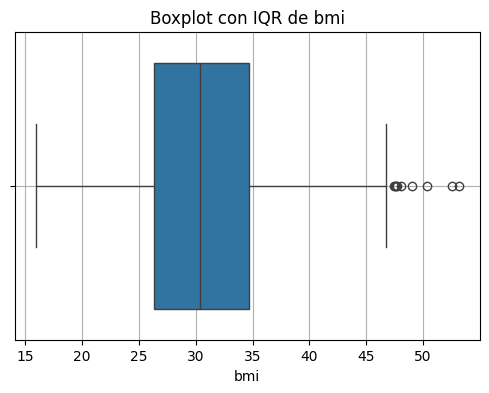

children: 0 outliers encontrados


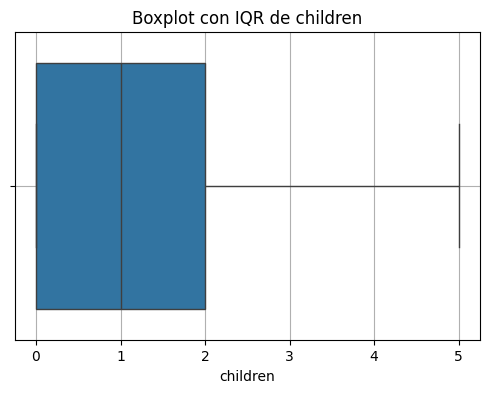

charges: 139 outliers encontrados


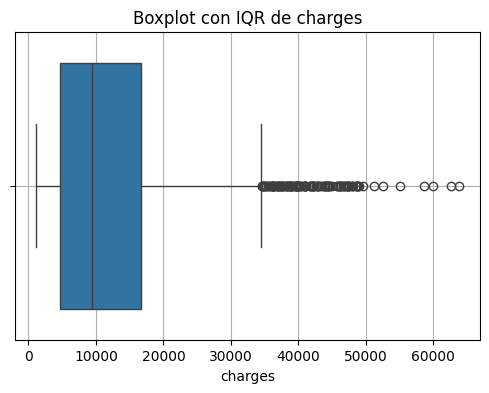

In [23]:
outlier_info = {}

for col in num_vars:
    Q1 = medical_insurance[col].quantile(0.25)
    Q3 = medical_insurance[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = medical_insurance[(medical_insurance[col] < lower_bound) | (medical_insurance[col] > upper_bound)]
    outlier_info[col] = len(outliers)

    print(f"{col}: {len(outliers)} outliers encontrados")
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=medical_insurance, x=col)
    plt.title(f"Boxplot con IQR de {col}")
    plt.grid(True)
    plt.show()


- Se han detectado outliers, especialmente en `bmi` y `charges`, lo cual puede afectar el rendimiento del modelo si no se trata.

In [24]:
# Eliminamos outliers basándonos en el IQR para las variables numéricas
for col in num_vars:
    Q1 = medical_insurance[col].quantile(0.25)
    Q3 = medical_insurance[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    medical_insurance = medical_insurance[(medical_insurance[col] >= lower_bound) & (medical_insurance[col] <= upper_bound)]

# Ahora medical_insurance_clean contiene los datos sin los outliers


In [25]:
# Observamos que 'region' tiene baja correlación con 'charges'
# Podemos verificar la correlación para asegurarnos de que es baja antes de eliminarla, como es categórica y no podemos ver la correlación, la codificamos con OneHot Encoder:
from sklearn.preprocessing import OneHotEncoder
# One-Hot Encoding de 'region' y calcular correlación
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_region = encoder.fit_transform(medical_insurance[['region']])

# Convertimos el resultado a un DataFrame
encoded_region_df = pd.DataFrame(encoded_region, columns=encoder.get_feature_names_out(['region']))

# Unimos el DataFrame con las columnas codificadas a df
medical_insurance_encoded = medical_insurance.join(encoded_region_df)

# Ahora calculamos la correlación solo con las variables numéricas
numerical_data = medical_insurance_encoded.select_dtypes(include=['int64', 'float64'])
correlation = numerical_data.corr()

# Mostramos la correlación de las variables con 'charges'
print("Correlación de variables con 'charges':")
print(correlation['charges'])

Correlación de variables con 'charges':
age                 0.448798
bmi                -0.064483
children            0.089083
charges             1.000000
region_northwest    0.017258
region_southeast    0.005452
region_southwest    0.012750
Name: charges, dtype: float64


In [26]:
medical_insurance.drop(columns=['region'], inplace=True)
print("Se ha eliminado la variable 'region' por baja correlación con 'charges'")

Se ha eliminado la variable 'region' por baja correlación con 'charges'


In [27]:

from sklearn.preprocessing import MinMaxScaler

medical_insurance["sex_n"] = pd.factorize(medical_insurance["sex"])[0]
medical_insurance["smoker_n"] = pd.factorize(medical_insurance["smoker"])[0]
num_variables = ["age", "bmi", "children", "sex_n", "smoker_n", "charges"]

scaler = MinMaxScaler()
scal_features = scaler.fit_transform(medical_insurance[num_variables])
medical_insurance_scal = pd.DataFrame(scal_features, index = medical_insurance.index, columns = num_variables)
medical_insurance_scal.head()

,age,bmi,children,sex_n,smoker_n,charges
0,0.021739,0.387788,0.0,0.0,0.0,0.475058
1,0.000000,0.578435,0.2,1.0,1.0,0.018193
2,0.217391,0.553426,0.6,1.0,1.0,0.100285
3,0.326087,0.219065,0.0,1.0,1.0,0.628746
4,0.304348,0.419617,0.0,1.0,1.0,0.082727


In [28]:
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.model_selection import train_test_split

X = medical_insurance_scal.drop("charges", axis = 1)
y = medical_insurance_scal["charges"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

selection_model = SelectKBest(f_regression, k = 4)
selection_model.fit(X_train, y_train)

selected_columns = X_train.columns[selection_model.get_support()]
X_train_sel = pd.DataFrame(selection_model.transform(X_train), columns = selected_columns)
X_test_sel = pd.DataFrame(selection_model.transform(X_test), columns = selected_columns)

X_train_sel.head()

,age,bmi,children,smoker_n
0,0.195652,0.465736,0.6,1.0
1,0.369565,0.596297,0.6,1.0
2,0.673913,0.610913,0.2,1.0
3,0.717391,0.764534,0.2,1.0
4,0.326087,0.567717,1.0,1.0


In [29]:
X_test_sel.head()

,age,bmi,children,smoker_n
0,0.782609,0.517701,0.2,1.0
1,0.260870,0.379506,0.2,1.0
2,0.652174,0.419617,0.2,1.0
3,0.782609,0.430010,0.2,1.0
4,0.369565,0.718902,0.4,1.0


In [30]:
X_train_sel["charges"] = y_train.values
X_test_sel["charges"] = y_test.values
X_train_sel.to_csv("clean_train.csv", index=False)
X_test_sel.to_csv("clean_test.csv", index=False)

- Se aplicaron técnicas de codificación y escalado para preparar los datos para el modelado.

### 1. Dividir el dataset en train y test

In [31]:
train_data = pd.read_csv("clean_train.csv")
test_data = pd.read_csv("clean_test.csv")

train_data.head()


,age,bmi,children,smoker_n,charges
0,0.195652,0.465736,0.6,1.0,0.094598
1,0.369565,0.596297,0.6,1.0,0.145037
2,0.673913,0.610913,0.2,1.0,0.255024
3,0.717391,0.764534,0.2,1.0,0.263950
4,0.326087,0.567717,1.0,1.0,0.166718


In [32]:
test_data.head()

,age,bmi,children,smoker_n,charges
0,0.782609,0.517701,0.2,1.0,0.295557
1,0.260870,0.379506,0.2,1.0,0.093886
2,0.652174,0.419617,0.2,1.0,0.244946
3,0.782609,0.430010,0.2,1.0,0.280707
4,0.369565,0.718902,0.4,1.0,0.717066


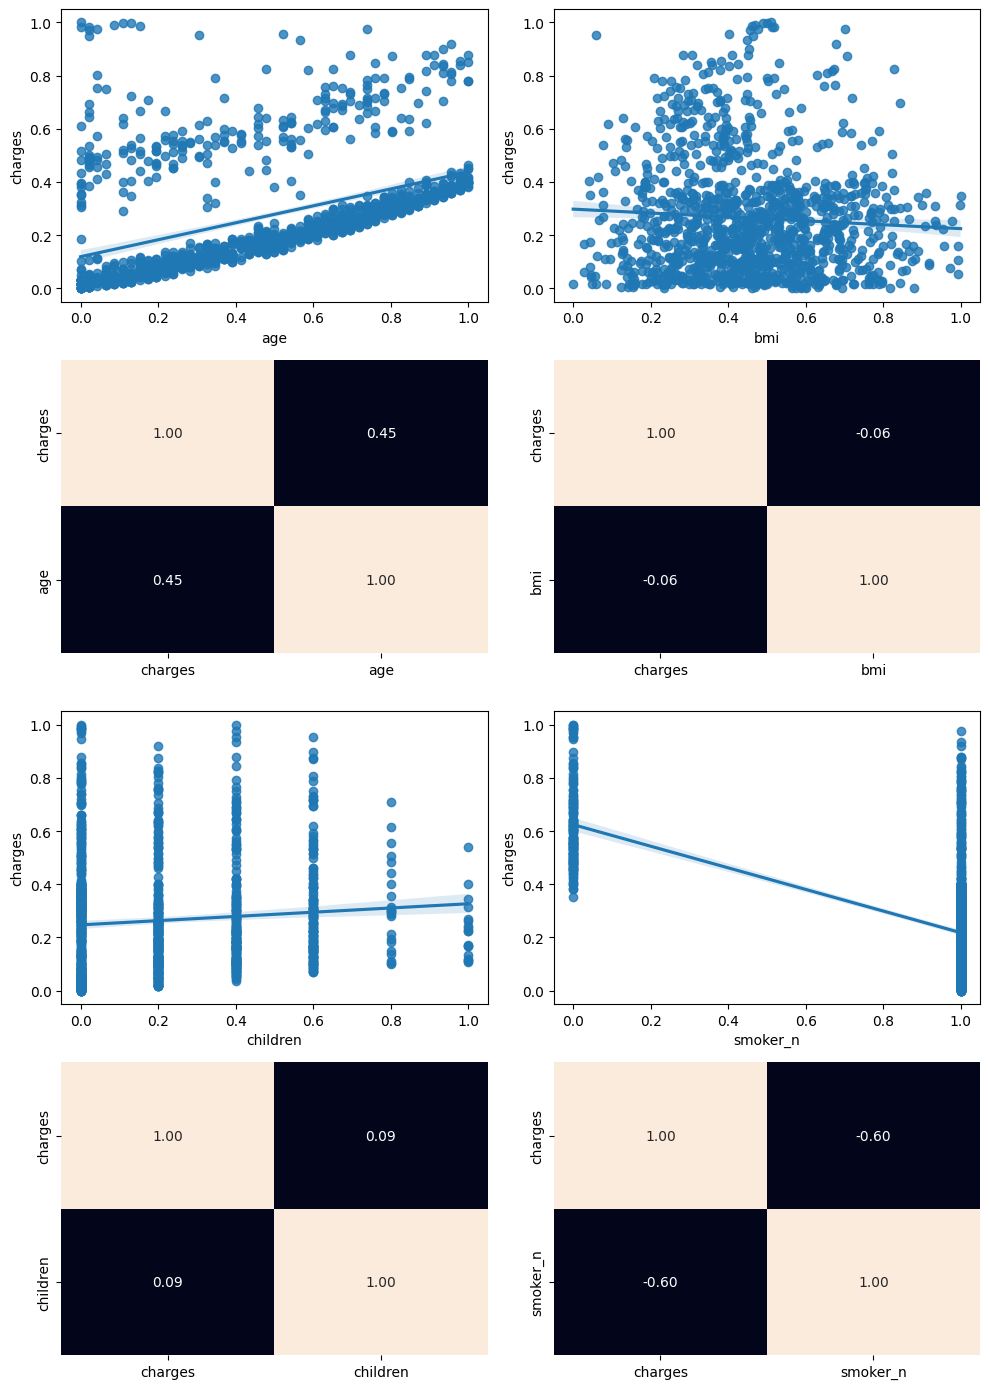

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axis = plt.subplots(4, 2, figsize = (10, 14))
medical_insurance = pd.concat([train_data, test_data])

sns.regplot(data = medical_insurance, x = "age", y = "charges", ax = axis[0, 0])
sns.heatmap(medical_insurance[["charges", "age"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 0], cbar = False)

sns.regplot(data = medical_insurance, x = "bmi", y = "charges", ax = axis[0, 1])
sns.heatmap(medical_insurance[["charges", "bmi"]].corr(), annot = True, fmt = ".2f", ax = axis[1, 1], cbar = False)

sns.regplot(data = medical_insurance, x = "children", y = "charges", ax = axis[2, 0])
sns.heatmap(medical_insurance[["charges", "children"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 0], cbar = False)

sns.regplot(data = medical_insurance, x = "smoker_n", y = "charges", ax = axis[2, 1])
sns.heatmap(medical_insurance[["charges", "smoker_n"]].corr(), annot = True, fmt = ".2f", ax = axis[3, 1], cbar = False)

plt.tight_layout()
plt.show()


### Analicemos cada par de diagrama de dispersión y mapa de calor:

**charges vs. age (cargos vs. edad)**

Diagrama de dispersión: Muestra una tendencia generalmente positiva. A medida que aumenta la 'age' (edad), los 'charges' (cargos) también tienden a aumentar. Los puntos están dispersos, lo que indica que la edad no es el único predictor de los cargos, pero hay una pendiente ascendente discernible en la línea de regresión.  
Mapa de calor: Muestra el coeficiente de correlación entre 'charges' y 'age', que es 0.45. Esto indica una correlación positiva moderada.

**charges vs. bmi (cargos vs. IMC)**

Diagrama de dispersión: Muestra una relación más débil y menos clara en comparación con 'age'. Podría haber una ligera tendencia positiva, pero los puntos están muy dispersos y la línea de regresión es casi plana.  
Mapa de calor: Muestra una correlación negativa muy débil de -0.06 entre 'charges' y 'bmi'. Esto sugiere que prácticamente no existe una relación lineal entre el índice de masa corporal y los gastos médicos en este conjunto de datos.

**charges vs. children (cargos vs. hijos)**

Diagrama de dispersión: Muestra la relación entre 'charges' y el número (escalado) de hijos. La variable 'children' parece tener valores discretos (apareciendo como bandas verticales de puntos). Hay una tendencia positiva muy ligera sugerida por la línea de regresión ligeramente ascendente, pero la relación es débil.  
Mapa de calor: Muestra una correlación positiva muy débil de 0.09 entre 'charges' y 'children'. Esto indica una relación lineal insignificante entre el número de hijos y los gastos médicos.

**charges vs. smoker_n (cargos vs. fumador_n)**

Diagrama de dispersión: Muestra una clara separación de 'charges' basada en la variable 'smoker_n'. Asumiendo que 'smoker_n' es 1 para fumadores y 0 para no fumadores, los puntos con 'smoker_n' = 1 tienden a tener 'charges' significativamente más altos que aquellos con 'smoker_n' = 0. La línea de regresión muestra una fuerte pendiente positiva.  
Mapa de calor: Muestra una fuerte correlación negativa de -0.60 entre 'charges' y 'smoker_n'. Esto probablemente se debe a que un valor de 1 en 'smoker_n' corresponde a fumadores que tienen cargos más altos, por lo tanto, una relación inversa al considerar la representación numérica. Si 'smoker_n' se hubiera codificado de manera que valores más altos significaran "más probable que sea fumador", la correlación probablemente sería positiva. La magnitud de 0.60 indica una relación lineal sustancial.

**Observaciones generales:**

'Age' (edad) y 'smoker_n'(estado de fumador) parecen tener las relaciones lineales más significativas con 'charges' (cargos) entre las características examinadas. 'Age' tiene una correlación positiva moderada, mientras que 'smoker_n' tiene una fuerte correlación negativa (debido a la probable codificación).  
'Bmi' (IMC) y 'children' (hijos) muestran relaciones lineales muy débiles con 'charges', lo que sugiere que no son predictores fuertes de los gastos médicos por sí solos en este contexto lineal.  

**Implicaciones para el modelado:**

Al construir un modelo para predecir 'charges', 'age' y el 'estado de fumador' probablemente serán características importantes. 'Bmi' y 'children' podrían tener un impacto lineal directo más débil, pero podrían interactuar con otras variables o tener relaciones no lineales con 'charges' que no se capturan mediante la simple correlación lineal.


In [34]:
X_train = train_data.drop(["charges"], axis = 1)
y_train = train_data["charges"]
X_test = test_data.drop(["charges"], axis = 1)
y_test = test_data["charges"]

In [35]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [36]:
print(f"Intercep (a): {model.intercept_}")
print(f"Coefficients (b1, b2): {model.coef_}")

Intercep (a): 0.47928525702483626
Coefficients (b1, b2): [ 0.33266462  0.03966183  0.05913456 -0.4482783 ]


In [37]:
y_pred = model.predict(X_test)
y_pred

array([0.32371305, 0.14466786, 0.27643183, 0.32023507, 0.20611503,
       0.32209251, 0.28210323, 0.59741527, 0.30284446, 0.28857041,
       0.27862917, 0.18119777, 0.07269619, 0.12712155, 0.35347378,
       0.25502435, 0.36767445, 0.22112908, 0.20417784, 0.13002636,
       0.32287968, 0.34619792, 0.2340867 , 0.57059548, 0.67010331,
       0.66655522, 0.10377688, 0.2257059 , 0.15017499, 0.34437627,
       0.24572683, 0.06544111, 0.29665887, 0.06328024, 0.09655938,
       0.07961172, 0.36561774, 0.28684537, 0.26196848, 0.06589516,
       0.35420443, 0.1233613 , 0.08508843, 0.10538207, 0.32905277,
       0.06543681, 0.30253278, 0.21777129, 0.32942343, 0.16168704,
       0.3537239 , 0.12909101, 0.15099222, 0.20323604, 0.11923421,
       0.13248564, 0.10010176, 0.24665788, 0.1932458 , 0.28995908,
       0.05490733, 0.24302029, 0.30946443, 0.25265662, 0.21527303,
       0.40776174, 0.59877678, 0.14056905, 0.37687674, 0.2674023 ,
       0.175253  , 0.05083143, 0.25689142, 0.2754954 , 0.69499

In [38]:
from sklearn.metrics import mean_squared_error, r2_score

print(f"MSE: {mean_squared_error(y_test, y_pred)}")
print(f"R2 Score: {r2_score(y_test, y_pred)}")

MSE: 0.018627583601281354
R2 Score: 0.6211530735028654


**Conclusiones Generales:**.  
 
Un R2 Score de 0.62 indica que todavía hay un 37.88% de la varianza que el modelo no explica, lo que implica que hay otros factores o ruido en los datos que el modelo no ha podido capturar.  

El error del modelo es relativamente bajo, especialmente si la variable objetivo está en una escala de 0 a 1. El MSE de 0.0186 sugiere que las predicciones no están demasiado lejos de los valores reales en promedio.  

Hay margen de mejora. El hecho de que el R2 Score no sea cercano a 1 indica que el modelo no es perfecto y que hay variabilidad en los datos que no está siendo explicada por las características utilizadas. 

La imagen muestra una serie de diagramas de dispersión y sus correspondientes mapas de calor de correlación para explorar las relaciones entre 'charges' (cargos, la variable objetivo, probablemente representando gastos médicos) y varias otras características: 'age' (edad), 'bmi' (índice de masa corporal), 'children' (hijos) y 'smoker_n' (probablemente una representación numérica del estado de fumador, quizás 1 para fumador y 0 para no fumador). Los datos parecen haber sido escalados entre 0 y 1 para 'age', 'bmi', 'children' y 'charges'.

Analicemos cada par de diagrama de dispersión y mapa de calor:

Esquina superior izquierda: **charges vs. age (cargos vs. edad)**

Diagrama de dispersión: Muestra una tendencia generalmente positiva. A medida que aumenta la 'age' (edad), los 'charges' (cargos) también tienden a aumentar. Los puntos están dispersos, lo que indica que la edad no es el único predictor de los cargos, pero hay una pendiente ascendente discernible en la línea de regresión.
Mapa de calor: Muestra el coeficiente de correlación entre 'charges' y 'age', que es 0.45. Esto indica una correlación positiva moderada.

Esquina superior derecha: **charges vs. bmi (cargos vs. IMC)**

Diagrama de dispersión: Muestra una relación más débil y menos clara en comparación con 'age'. Podría haber una ligera tendencia positiva, pero los puntos están muy dispersos y la línea de regresión es casi plana.
Mapa de calor: Muestra una correlación negativa muy débil de -0.06 entre 'charges' y 'bmi'. Esto sugiere que prácticamente no existe una relación lineal entre el índice de masa corporal y los gastos médicos en este conjunto de datos.

Esquina inferior izquierda: **charges vs. children (cargos vs. hijos)**

Diagrama de dispersión: Muestra la relación entre 'charges' y el número (escalado) de hijos. La variable 'children' parece tener valores discretos (apareciendo como bandas verticales de puntos). Hay una tendencia positiva muy ligera sugerida por la línea de regresión ligeramente ascendente, pero la relación es débil.
Mapa de calor: Muestra una correlación positiva muy débil de 0.09 entre 'charges' y 'children'. Esto indica una relación lineal insignificante entre el número de hijos y los gastos médicos.

Esquina inferior derecha: **charges vs. smoker_n (cargos vs. fumador_n)**

Diagrama de dispersión: Muestra una clara separación de 'charges' basada en la variable 'smoker_n'. Asumiendo que 'smoker_n' es 1 para fumadores y 0 para no fumadores, los puntos con 'smoker_n' = 1 tienden a tener 'charges' significativamente más altos que aquellos con 'smoker_n' = 0. La línea de regresión muestra una fuerte pendiente positiva.
Mapa de calor: Muestra una fuerte correlación negativa de -0.60 entre 'charges' y 'smoker_n'. Esto probablemente se debe a que un valor de 1 en 'smoker_n' corresponde a fumadores que tienen cargos más altos, por lo tanto, una relación inversa al considerar la representación numérica. Si 'smoker_n' se hubiera codificado de manera que valores más altos significaran "más probable que sea fumador", la correlación probablemente sería positiva. La magnitud de 0.60 indica una relación lineal sustancial.

**Observaciones generales:**

'Age' (edad) y 'smoker_n' (estado de fumador) parecen tener las relaciones lineales más significativas con 'charges' (cargos) entre las características examinadas. 'Age' tiene una correlación positiva moderada, mientras que 'smoker_n' tiene una fuerte correlación negativa (debido a la probable codificación).
    'Bmi' (IMC) y 'children' (hijos) muestran relaciones lineales muy débiles con 'charges', lo que sugiere que no son predictores fuertes de los gastos médicos por sí solos en este contexto lineal.
    Los diagramas de dispersión proporcionan una confirmación visual de los coeficientes de correlación. La dispersión de los puntos alrededor de la línea de regresión indica la fuerza y la linealidad de la relación. Una dispersión más ajustada sugiere una relación lineal más fuerte.

**Implicaciones para el modelado:**

Al construir un modelo para predecir 'charges', 'age' y el 'estado de fumador' probablemente serán características importantes. 'Bmi' y 'children' podrían tener un impacto lineal directo más débil, pero podrían interactuar con otras variables o tener relaciones no lineales con 'charges' que no se capturan mediante la simple correlación lineal.


In [39]:
X_train = train_data.drop(["charges"], axis = 1)
y_train = train_data["charges"]
X_test = test_data.drop(["charges"], axis = 1)
y_test = test_data["charges"]